✅ Libraries loaded successfully

📥 Downloading data from 2024-06-25 to 2026-06-15 ...


[*********************100%***********************]  1 of 1 completed


  EURUSD=X: 12157 rows downloaded


[*********************100%***********************]  1 of 1 completed


  GBPUSD=X: 12158 rows downloaded

✅ Merged dataset shape: (12159, 2)
✅ Features engineered. Final shape: (12158, 6)
✅ Sequences built — X: (12134, 24, 4), y: (12134,)
✅ Train: 9707 samples | Test: 2427 samples


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 50)         │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,251 (122.07 KB)

 Trainable params: 31,251 (122.07 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training started ...

Epoch 1/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - loss: 0.0086 - val_loss: 0.0012
Epoch 2/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 3/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 4/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0026 - val_loss: 0.0013
Epoch 5/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 6/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 7/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 8/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 9/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - loss: 0.0020 - val_loss: 0.0012
Epoch 10/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.0019 - val_loss: 0.0012
Epoch 11/50
304/304 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 0.0018 - val_loss: 0.0012
Epoch

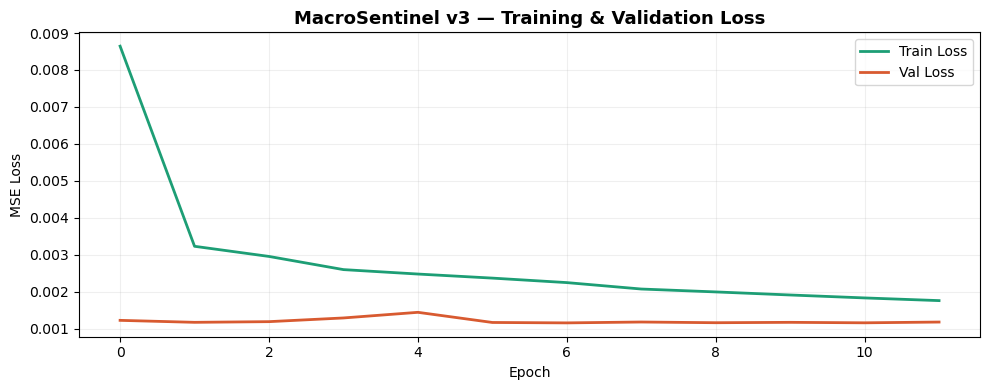

📊 Chart 1 saved: chart1_loss_curve.png


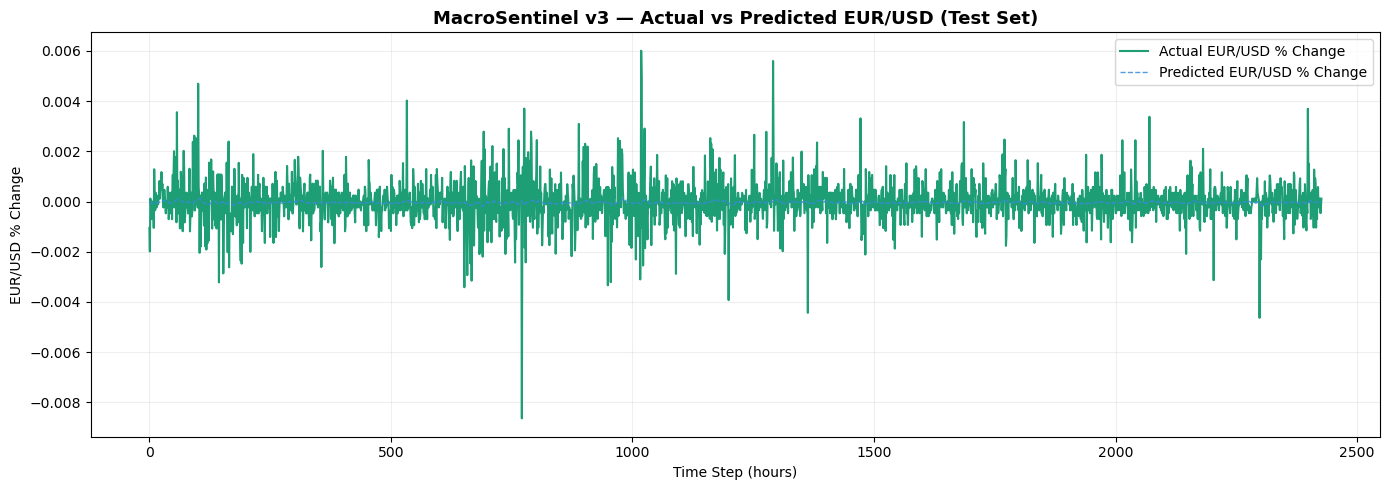

📊 Chart 2 saved: chart2_actual_vs_predicted.png


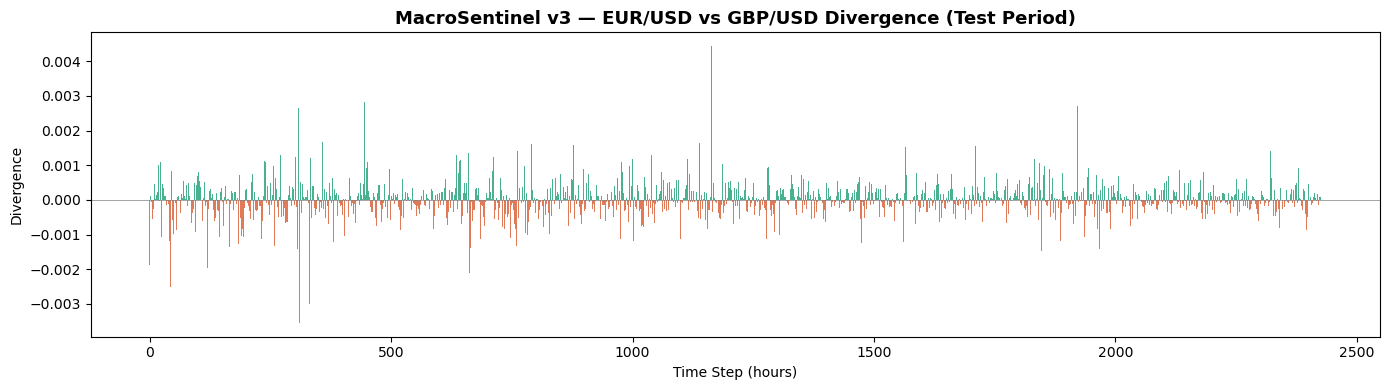

📊 Chart 3 saved: chart3_divergence.png


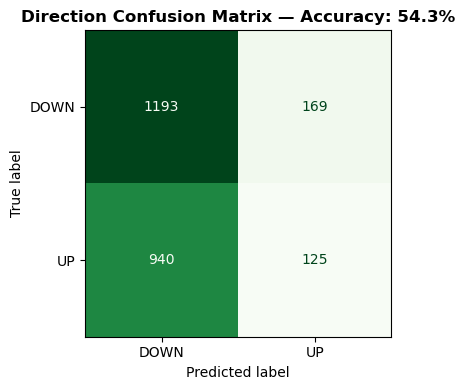

📊 Chart 4 saved: chart4_confusion_matrix.png


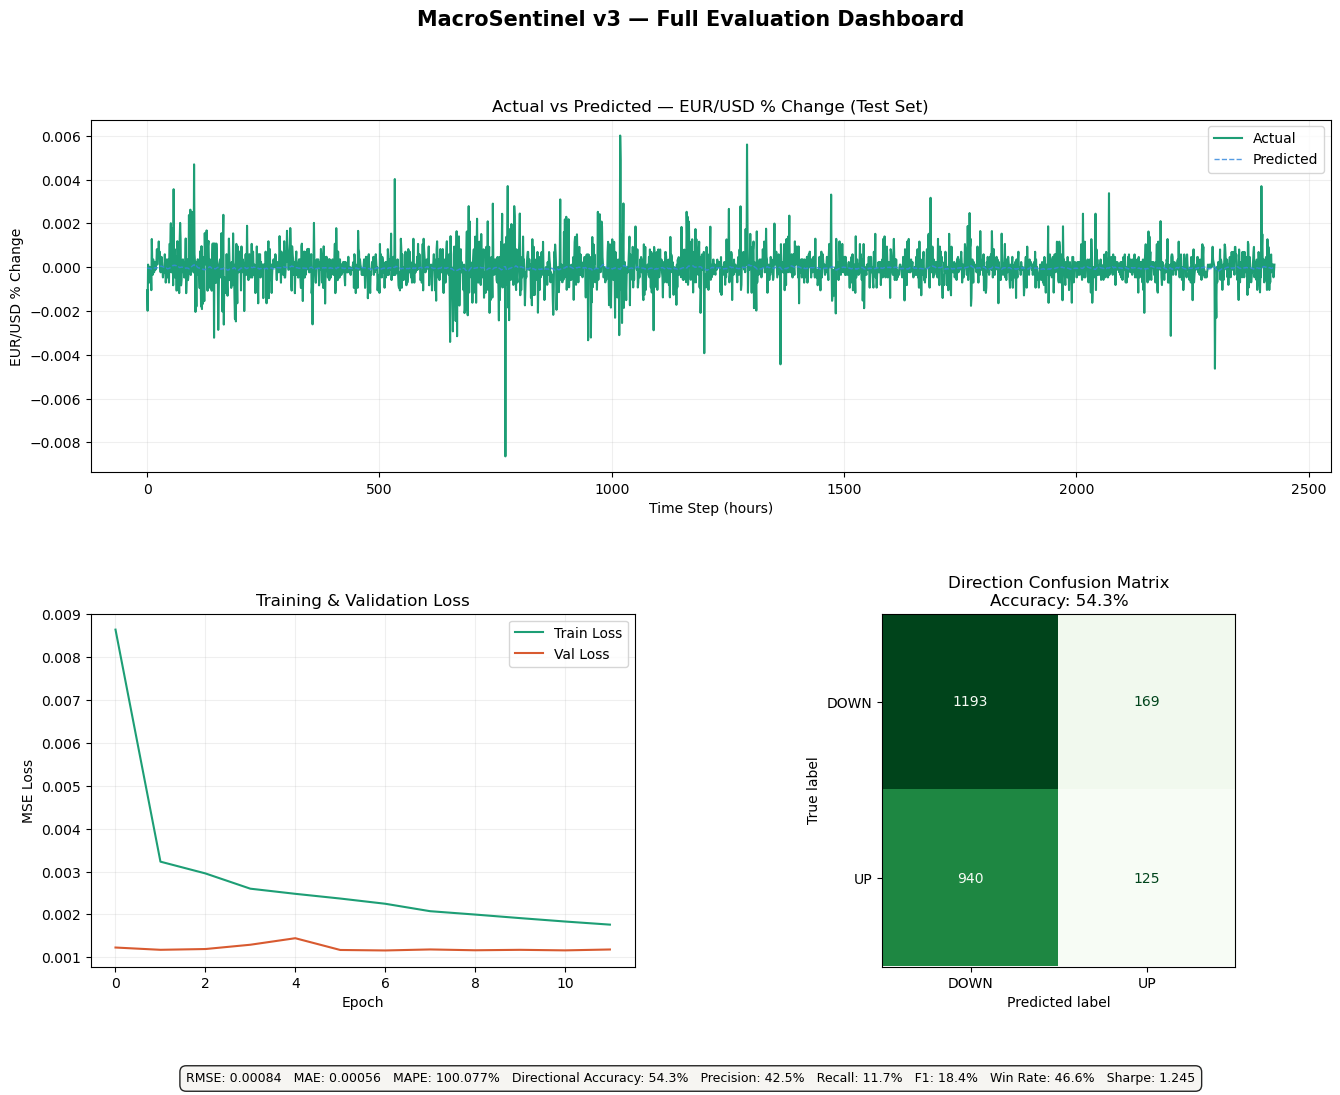

📊 Chart 5 saved: chart5_dashboard.png

  ✅ MacroSentinel v3 run complete!

  Files saved:
  • macrosentinel_model.keras   (trained model)
  • chart1_loss_curve.png
  • chart2_actual_vs_predicted.png
  • chart3_divergence.png
  • chart4_confusion_matrix.png
  • chart5_dashboard.png        (full summary)



In [1]:
# ============================================================
#  MacroSentinel v3 FINAL — Complete LSTM Forex Model
#  Run this file top to bottom in Jupyter or as a .py script
#  Everything is included: data, training, metrics, charts
# ============================================================

# Suppress TensorFlow GPU warning (Windows only)
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ============================================================
# 1. Import Libraries
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

print("✅ Libraries loaded successfully")

# ============================================================
# 2. Download Forex Data (EUR/USD and GBP/USD)
#    Uses a rolling 720-day window so it always stays within
#    Yahoo Finance's 730-day hourly data limit
# ============================================================
symbols = ['EURUSD=X', 'GBPUSD=X']
data = {}

end_date   = datetime.today()
start_date = end_date - timedelta(days=720)

print(f"\n📥 Downloading data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')} ...")

for sym in symbols:
    df = yf.download(sym,
                     start=start_date.strftime('%Y-%m-%d'),
                     end=end_date.strftime('%Y-%m-%d'),
                     interval='1h')
    df = df[['Close']].rename(columns={'Close': sym})
    data[sym] = df
    print(f"  {sym}: {len(df)} rows downloaded")

# Merge and forward-fill gaps
df_all = pd.concat([data[sym] for sym in symbols], axis=1).ffill()
print(f"\n✅ Merged dataset shape: {df_all.shape}")

# ============================================================
# 3. Feature Engineering
# ============================================================
for sym in symbols:
    df_all[sym + '_pct'] = df_all[sym].pct_change()

# Divergence: spread between EUR/USD and GBP/USD pct moves
df_all['divergence'] = df_all['EURUSD=X_pct'] - df_all['GBPUSD=X_pct']

df_all = df_all.dropna()

# ── Dummy news sentiment ──────────────────────────────────────
# Replace this block later with a real NLP/news API feed
np.random.seed(42)
df_all['news_sentiment'] = np.random.uniform(-1, 1, len(df_all))
# ─────────────────────────────────────────────────────────────

print(f"✅ Features engineered. Final shape: {df_all.shape}")

# ============================================================
# 4. Scale Features
# ============================================================
features = [sym + '_pct' for sym in symbols] + ['divergence', 'news_sentiment']

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_all[features])

# ============================================================
# 5. Build Sequences (24-hour lookback window)
# ============================================================
timesteps = 24
X, y = [], []

for i in range(timesteps, len(scaled)):
    X.append(scaled[i - timesteps:i])
    y.append(scaled[i, 0])   # target: next EUR/USD pct change

X, y = np.array(X), np.array(y)
print(f"✅ Sequences built — X: {X.shape}, y: {y.shape}")

# ============================================================
# 6. Train / Test Split (80 / 20)
# ============================================================
split    = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"✅ Train: {len(X_train)} samples | Test: {len(X_test)} samples")

# ============================================================
# 7. Build Stacked LSTM Model with Dropout
# ============================================================
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# ============================================================
# 8. Train with Early Stopping
# ============================================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("\n🚀 Training started ...\n")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    verbose=1,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)
print("\n✅ Training complete")

# ============================================================
# 9. Save Model (native Keras format)
# ============================================================
model.save('macrosentinel_model.keras')
print("✅ Model saved to macrosentinel_model.keras")
print("   To reload later: model = load_model('macrosentinel_model.keras')")

# ============================================================
# 10. Predict on Train and Test sets
# ============================================================
print("\n🔮 Running predictions ...")
y_pred_train = model.predict(X_train, verbose=0)
y_pred_test  = model.predict(X_test,  verbose=0)

# ============================================================
# 11. Inverse Transform — back to real pct-change scale
# ============================================================
def invert_scaling(y_scaled, n_features):
    dummy          = np.zeros((len(y_scaled), n_features))
    dummy[:, 0]    = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

n_feat       = len(features)
train_actual = invert_scaling(y_train,      n_feat)
train_pred   = invert_scaling(y_pred_train, n_feat)
test_actual  = invert_scaling(y_test,       n_feat)
test_pred    = invert_scaling(y_pred_test,  n_feat)

print("✅ Inverse transform done")

# ============================================================
# 12. METRICS — Error Magnitude
# ============================================================
def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

rmse_train = np.sqrt(mean_squared_error(train_actual, train_pred))
rmse_test  = np.sqrt(mean_squared_error(test_actual,  test_pred))
mae_train  = mean_absolute_error(train_actual, train_pred)
mae_test   = mean_absolute_error(test_actual,  test_pred)
mape_train = mape(train_actual, train_pred)
mape_test  = mape(test_actual,  test_pred)

# ============================================================
# 13. METRICS — Directional Accuracy
# ============================================================
def directional_labels(arr):
    return (arr > 0).astype(int)

dir_actual = directional_labels(test_actual)
dir_pred   = directional_labels(test_pred)

da_test   = np.mean(dir_actual == dir_pred) * 100
precision = precision_score(dir_actual, dir_pred, zero_division=0) * 100
recall    = recall_score(dir_actual,    dir_pred, zero_division=0) * 100
f1        = f1_score(dir_actual,        dir_pred, zero_division=0) * 100
cm        = confusion_matrix(dir_actual, dir_pred)

# ============================================================
# 14. METRICS — Trading Performance
# ============================================================
positions  = np.where(dir_pred == 1, 1, 0)
pnl        = test_actual * positions

win_rate   = np.mean(pnl[pnl != 0] > 0) * 100 if np.any(pnl != 0) else 0.0

trading_hours_per_year = 6500
mean_ret     = np.mean(pnl)
std_ret      = np.std(pnl)
sharpe_ratio = (mean_ret / std_ret * np.sqrt(trading_hours_per_year)
                if std_ret != 0 else 0.0)

# ============================================================
# 15. Print Full Metrics Summary
# ============================================================
sep = "=" * 52
print(f"\n{sep}")
print("   MacroSentinel v3 — Full Evaluation Report")
print(sep)
print(f"\n  ERROR MAGNITUDE")
print(f"  {'Metric':<24} {'Train':>10} {'Test':>10}")
print(f"  {'-'*44}")
print(f"  {'RMSE':<24} {rmse_train:>10.6f} {rmse_test:>10.6f}")
print(f"  {'MAE':<24} {mae_train:>10.6f} {mae_test:>10.6f}")
print(f"  {'MAPE':<24} {mape_train:>9.4f}% {mape_test:>9.4f}%")
print(f"\n  DIRECTIONAL ACCURACY (test set)")
print(f"  {'Directional Accuracy':<24} {da_test:>9.2f}%")
print(f"  {'Precision (BUY)':<24} {precision:>9.2f}%")
print(f"  {'Recall (BUY)':<24} {recall:>9.2f}%")
print(f"  {'F1 Score':<24} {f1:>9.2f}%")
print(f"\n  TRADING PERFORMANCE (test set)")
print(f"  {'Win Rate':<24} {win_rate:>9.2f}%")
print(f"  {'Sharpe Ratio':<24} {sharpe_ratio:>10.4f}")
print(f"\n{sep}\n")

# ============================================================
# 16. CHART 1 — Training Loss Curve
# ============================================================
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='#1D9E75', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss',   color='#D85A30', linewidth=2)
plt.title('MacroSentinel v3 — Training & Validation Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('chart1_loss_curve.png', dpi=150)
plt.show()
print("📊 Chart 1 saved: chart1_loss_curve.png")

# ============================================================
# 17. CHART 2 — Actual vs Predicted (Test Set)
# ============================================================
plt.figure(figsize=(14, 5))
plt.plot(test_actual, label='Actual EUR/USD % Change',
         color='#1D9E75', linewidth=1.5)
plt.plot(test_pred,   label='Predicted EUR/USD % Change',
         color='#378ADD', linewidth=1, linestyle='--', alpha=0.85)
plt.title('MacroSentinel v3 — Actual vs Predicted EUR/USD (Test Set)',
          fontsize=13, fontweight='bold')
plt.xlabel('Time Step (hours)')
plt.ylabel('EUR/USD % Change')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('chart2_actual_vs_predicted.png', dpi=150)
plt.show()
print("📊 Chart 2 saved: chart2_actual_vs_predicted.png")

# ============================================================
# 18. CHART 3 — Divergence Bar Chart
# ============================================================
div_test = df_all['divergence'].values[timesteps + split:]
plt.figure(figsize=(14, 4))
colors = ['#1D9E75' if v > 0 else '#D85A30' for v in div_test]
plt.bar(range(len(div_test)), div_test, color=colors, width=1.0, alpha=0.8)
plt.axhline(0, color='gray', linewidth=0.5)
plt.title('MacroSentinel v3 — EUR/USD vs GBP/USD Divergence (Test Period)',
          fontsize=13, fontweight='bold')
plt.xlabel('Time Step (hours)')
plt.ylabel('Divergence')
plt.tight_layout()
plt.savefig('chart3_divergence.png', dpi=150)
plt.show()
print("📊 Chart 3 saved: chart3_divergence.png")

# ============================================================
# 19. CHART 4 — Confusion Matrix
# ============================================================
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['DOWN', 'UP'])
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Direction Confusion Matrix — Accuracy: {da_test:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_confusion_matrix.png', dpi=150)
plt.show()
print("📊 Chart 4 saved: chart4_confusion_matrix.png")

# ============================================================
# 20. CHART 5 — Full 4-Panel Summary Dashboard
# ============================================================
fig = plt.figure(figsize=(16, 11))
fig.suptitle('MacroSentinel v3 — Full Evaluation Dashboard',
             fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.28)

# Panel A: Actual vs Predicted
axA = fig.add_subplot(gs[0, :])
axA.plot(test_actual, label='Actual',    color='#1D9E75', linewidth=1.5)
axA.plot(test_pred,   label='Predicted', color='#378ADD', linewidth=1,
         linestyle='--', alpha=0.85)
axA.set_title('Actual vs Predicted — EUR/USD % Change (Test Set)')
axA.set_xlabel('Time Step (hours)')
axA.set_ylabel('EUR/USD % Change')
axA.legend()
axA.grid(alpha=0.2)

# Panel B: Loss curve
axB = fig.add_subplot(gs[1, 0])
axB.plot(history.history['loss'],     label='Train Loss', color='#1D9E75')
axB.plot(history.history['val_loss'], label='Val Loss',   color='#D85A30')
axB.set_title('Training & Validation Loss')
axB.set_xlabel('Epoch')
axB.set_ylabel('MSE Loss')
axB.legend()
axB.grid(alpha=0.2)

# Panel C: Confusion matrix
axC = fig.add_subplot(gs[1, 1])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=['DOWN', 'UP'])
disp2.plot(ax=axC, colorbar=False, cmap='Greens')
axC.set_title(f'Direction Confusion Matrix\nAccuracy: {da_test:.1f}%')

# Metrics strip at bottom
metrics_text = (
    f"RMSE: {rmse_test:.5f}   MAE: {mae_test:.5f}   MAPE: {mape_test:.3f}%   "
    f"Directional Accuracy: {da_test:.1f}%   "
    f"Precision: {precision:.1f}%   Recall: {recall:.1f}%   F1: {f1:.1f}%   "
    f"Win Rate: {win_rate:.1f}%   Sharpe: {sharpe_ratio:.3f}"
)
fig.text(0.5, 0.005, metrics_text, ha='center', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f4f0', alpha=0.85))

plt.savefig('chart5_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart 5 saved: chart5_dashboard.png")

# ============================================================
# DONE
# ============================================================
print(f"""
{'='*52}
  ✅ MacroSentinel v3 run complete!
  
  Files saved:
  • macrosentinel_model.keras   (trained model)
  • chart1_loss_curve.png
  • chart2_actual_vs_predicted.png
  • chart3_divergence.png
  • chart4_confusion_matrix.png
  • chart5_dashboard.png        (full summary)
{'='*52}
""")

# ============================================================
# TO RELOAD THE MODEL IN A FUTURE SESSION:
# from tensorflow.keras.models import load_model
# model = load_model('macrosentinel_model.keras')
# ============================================================
